# General settings

In [1]:
import os

# You can only use one GPU at a time
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
os.environ["OMP_NUM_THREADS"] = "32"
os.environ["MKL_NUM_THREADS"] = "32"

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import lightning as L
from lightning import Callback
from lightning.pytorch import Trainer

import matplotlib.pyplot as plt
import numpy as np

from vv.evaluation.eval_logger import InMemoryLogger
from vv.models.latent_diffusion_copy.vq_model import VQModel
from vv.logger.codebook_util_logger import CodebookAnalyzer

# Data

In [3]:
# Define the shape of the images (e.g., 3 channels, 224x224 resolution)
image_shape = (3, 256, 256)
batch_size = 15
num_batches = 10

# Generate random image-shaped tensors
dataset_1 = torch.rand(batch_size * num_batches, *image_shape)
tensor_dataset_1 = TensorDataset(dataset_1)

class ImageDataModule(L.LightningDataModule):
    def __init__(self, dataset, batch_size):
        super().__init__()
        self.dataset = dataset
        self.batch_size = batch_size

    def setup(self, stage=None):
        # Split the dataset into train, val, and test (using the same data for simplicity)
        self.train_dataset = self.dataset
        self.val_dataset = self.dataset
        self.test_dataset = self.dataset

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

# Create the data module
data_module = ImageDataModule(tensor_dataset_1, batch_size=batch_size)
data_module.setup()

# Model

In [4]:
model_args = {
    "learning_rate": 4.5e-06,
    "embed_dim": 32,
    "n_embed": 512,
    "num_spaces": 8,
    "distance_type": "l2",
    "analyze_codebook_usage": True,
    "split_quantizer": True,
    "monitor": "val/rec_loss",
    "ddconfig": {
        "double_z": False,
        "z_channels": 256,
        "resolution": 256,
        "in_channels": 3,
        "out_ch": 3,
        "ch": 128,
        "ch_mult": [1, 1, 2, 2, 4],
        "num_res_blocks": 2,
        "attn_resolutions": [16],
        "dropout": 0.0,
    },
    "lossconfig": {
        "target": "vv.models.latent_diffusion_copy.loss.VQLPIPSWithDiscriminator",
        "params": {
            "disc_conditional": False,
            "disc_in_channels": 3,
            "disc_num_layers": 3,
            "disc_start": 1,
            "disc_weight": 0.8,
            "codebook_weight": 1.0,
        },
    },
}

# Initialize model with required arguments
model = VQModel(**model_args)

# Mute model logging
model.log = lambda *args, **kwargs: None

print("Model successfully loaded!")

making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels


./venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
./venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
VQLPIPSWithDiscriminator running with hinge loss.
Using SplitVectorQuantiser with distance type: l2
Model successfully loaded!


# Trainer

In [ ]:
logger = InMemoryLogger()
codebook_util_logger = CodebookAnalyzer(tag_name="codebook_util")

In [6]:
trainer = Trainer(
    logger=logger,
    callbacks=[codebook_util_logger]
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


# Run

In [7]:
trainer.validate(model, datamodule=data_module, verbose=False)

You are using a CUDA device ('NVIDIA H200') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [7]
./venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.


Validation DataLoader 0: 100%|██████████| 10/10 [00:02<00:00,  4.54it/s]


[{}]

# Evaluate

In [8]:
result = logger.get_histogram()

In [9]:
print(result["values"].shape)
print(result["values"])

torch.Size([512])
Parameter containing:
tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 3.5000e+01, 0.0000e+00,
        1.0500e+02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 7.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 3.3000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,


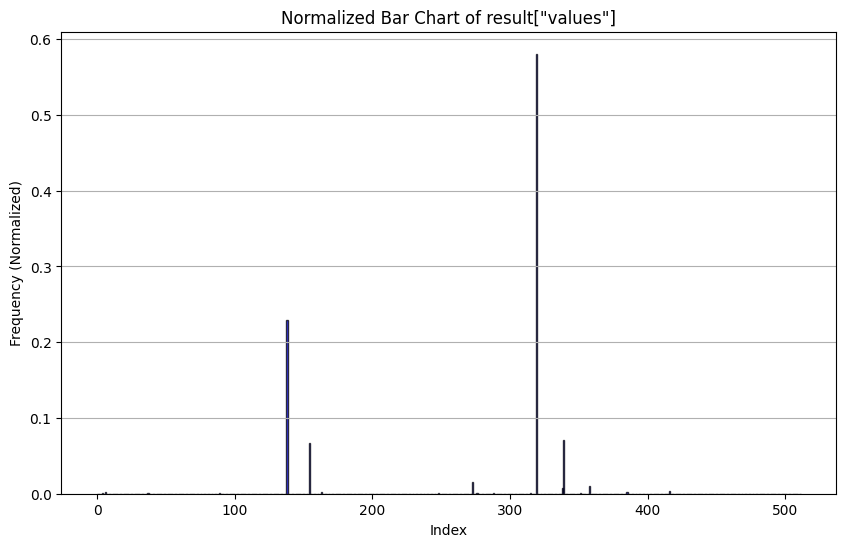

In [12]:
counts = result["values"].cpu().numpy()  # Convert tensor to numpy array if on GPU

# Define the range of indices
indices = np.arange(len(counts))

# Normalize the counts
normalized_counts = counts / counts.sum()

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(indices, normalized_counts, color='blue', alpha=0.75, edgecolor='black')
plt.title('Normalized Bar Chart of result["values"]')
plt.xlabel('Index')
plt.ylabel('Frequency (Normalized)')
plt.grid(True, axis='y')
plt.show()